In [15]:
#!pip install ema_workbench

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.7/28.7 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.4/124.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 47.4 MB/s eta 0:00:00


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print(np.__version__)
print(np.__file__)
print(hasattr(np, "bool"))

data = pd.read_excel(
    "SCI_2025_reshaped_rows_asiaR5.xlsx",
    sheet_name="Data"
)

# Remove units row
data = data.iloc[1:].reset_index(drop=True)

# Convert all columns except Model and Scenario
for col in data.columns[2:]:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Remove rows with missing values
data = data.dropna()

print(data.shape)
print(data.dtypes)

2.0.2
/usr/local/lib/python3.12/dist-packages/numpy/__init__.py
True
(763, 15)
Model                      object
Scenario                   object
Emissions|CO2             float64
Final Energy              float64
Primary Energy            float64
Primary Energy|Coal       float64
Primary Energy|Oil        float64
Primary Energy|Gas        float64
Primary Energy|Biomass    float64
Primary Energy|Nuclear    float64
Primary Energy|Solar      float64
Primary Energy|Wind       float64
Population                float64
Consumption               float64
GDP|PPP                   float64
dtype: object


In [6]:
data

,Model,Scenario,Emissions|CO2,Final Energy,Primary Energy,Primary Energy|Coal,Primary Energy|Oil,Primary Energy|Gas,Primary Energy|Biomass,Primary Energy|Nuclear,Primary Energy|Solar,Primary Energy|Wind,Population,Consumption,GDP|PPP
30,AIM/CGE 2.1,COMMIT-Bridge,1490.964400,135.379900,190.471600,13.184700,43.504900,32.013900,60.888000,10.387600,7.646700,13.149400,4222.755500,43645.890822,164766.881125
31,AIM/CGE 2.1,COMMIT-Current-Policies,21334.842500,220.687100,319.469400,144.430100,76.450900,36.940800,38.722100,4.952200,3.094200,5.885700,4222.755500,47239.165919,172134.960044
42,AIM/CGE V2.2,ENGAGE-INDCi2030-1000f,-2214.734300,211.131600,298.015400,17.415800,33.856900,10.115300,78.628100,13.216800,70.142700,67.368900,3717.267800,78075.972800,320776.233900
43,AIM/CGE V2.2,ENGAGE-INDCi2030-1200,402.804500,210.114200,288.814900,21.732200,40.173300,12.515200,57.721600,12.785100,68.834100,67.553600,3717.267800,78868.452800,321522.285800
44,AIM/CGE V2.2,ENGAGE-INDCi2030-1200f,-2128.590500,210.326300,304.875200,26.634500,33.878600,12.779900,78.137100,12.163800,68.167300,65.803800,3717.267800,78109.969600,320635.639100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,-1238.069074,182.608796,249.960622,24.341666,6.466796,10.485879,53.869002,4.670304,40.642675,88.529895,3463.373932,52723.083183,190143.738532
1553,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1600,1054.441550,197.879019,265.002962,24.341666,19.600362,17.492739,53.716040,4.507012,38.902501,85.814871,3463.373932,55856.777036,199683.845016
1554,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,-3091.639939,170.106168,242.746472,24.341666,5.425961,5.733540,52.086267,4.474065,41.186578,88.936527,3463.373932,47748.325674,173509.296485
1555,WITCH-GLOBIOM 4.4,CD-LINKS-NPi,33120.676065,258.867177,471.083064,156.408037,139.843841,68.941379,16.644802,3.854320,16.675065,49.393427,3463.373932,60725.519772,211196.678593


In [26]:
data["Consumption_per_capita"] = (
    data["Consumption"] / data["Population"]
)

data["Final_Energy_per_capita"] = (
    data["Final Energy"] / data["Population"]
)

# Check
print(data[[
    "Consumption",
    "Final Energy",
    "Population",
    "Consumption_per_capita",
    "Final_Energy_per_capita"
]].head())

     Consumption  Final Energy  Population  Consumption_per_capita  \
30  43645.890822      135.3799   4222.7555               10.335879   
31  47239.165919      220.6871   4222.7555               11.186811   
42  78075.972800      211.1316   3717.2678               21.003591   
43  78868.452800      210.1142   3717.2678               21.216780   
44  78109.969600      210.3263   3717.2678               21.012737   

    Final_Energy_per_capita  
30                 0.032060  
31                 0.052261  
42                 0.056798  
43                 0.056524  
44                 0.056581  


In [27]:
data

,Model,Scenario,Emissions|CO2,Final Energy,Primary Energy,Primary Energy|Coal,Primary Energy|Oil,Primary Energy|Gas,Primary Energy|Biomass,Primary Energy|Nuclear,Primary Energy|Solar,Primary Energy|Wind,Population,Consumption,GDP|PPP,Consumption_per_capita,Final_Energy_per_capita
30,AIM/CGE 2.1,COMMIT-Bridge,1490.964400,135.379900,190.471600,13.184700,43.504900,32.013900,60.888000,10.387600,7.646700,13.149400,4222.755500,43645.890822,164766.881125,10.335879,0.032060
31,AIM/CGE 2.1,COMMIT-Current-Policies,21334.842500,220.687100,319.469400,144.430100,76.450900,36.940800,38.722100,4.952200,3.094200,5.885700,4222.755500,47239.165919,172134.960044,11.186811,0.052261
42,AIM/CGE V2.2,ENGAGE-INDCi2030-1000f,-2214.734300,211.131600,298.015400,17.415800,33.856900,10.115300,78.628100,13.216800,70.142700,67.368900,3717.267800,78075.972800,320776.233900,21.003591,0.056798
43,AIM/CGE V2.2,ENGAGE-INDCi2030-1200,402.804500,210.114200,288.814900,21.732200,40.173300,12.515200,57.721600,12.785100,68.834100,67.553600,3717.267800,78868.452800,321522.285800,21.216780,0.056524
44,AIM/CGE V2.2,ENGAGE-INDCi2030-1200f,-2128.590500,210.326300,304.875200,26.634500,33.878600,12.779900,78.137100,12.163800,68.167300,65.803800,3717.267800,78109.969600,320635.639100,21.012737,0.056581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,-1238.069074,182.608796,249.960622,24.341666,6.466796,10.485879,53.869002,4.670304,40.642675,88.529895,3463.373932,52723.083183,190143.738532,15.223041,0.052726
1553,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1600,1054.441550,197.879019,265.002962,24.341666,19.600362,17.492739,53.716040,4.507012,38.902501,85.814871,3463.373932,55856.777036,199683.845016,16.127851,0.057135
1554,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,-3091.639939,170.106168,242.746472,24.341666,5.425961,5.733540,52.086267,4.474065,41.186578,88.936527,3463.373932,47748.325674,173509.296485,13.786650,0.049116
1555,WITCH-GLOBIOM 4.4,CD-LINKS-NPi,33120.676065,258.867177,471.083064,156.408037,139.843841,68.941379,16.644802,3.854320,16.675065,49.393427,3463.373932,60725.519772,211196.678593,17.533631,0.074744


In [37]:
data.describe()

,Emissions|CO2,Final Energy,Primary Energy,Primary Energy|Coal,Primary Energy|Oil,Primary Energy|Gas,Primary Energy|Biomass,Primary Energy|Nuclear,Primary Energy|Solar,Primary Energy|Wind,Population,Consumption,GDP|PPP,Consumption_per_capita,Final_Energy_per_capita
count,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000
mean,4456.857443,239.294318,318.516336,35.857607,30.222930,40.658681,44.282657,19.877705,81.868842,51.639290,3680.419149,107575.890716,241588.558134,29.243747,0.065079
std,8975.095153,59.381651,82.615559,58.059923,32.157801,25.093420,18.831115,21.937252,45.827021,22.438610,298.869340,64477.441659,38323.852705,17.134824,0.016520
min,-5639.568909,77.165300,114.091375,0.000000,0.000000,0.000946,1.076145,0.000000,2.659047,2.993990,2722.744000,0.000000,96702.596493,0.000000,0.022957
25%,-814.653073,192.329358,268.473581,1.666371,8.719453,20.864555,28.969315,2.700727,41.462196,39.198593,3714.187814,54232.096300,225052.972927,14.437371,0.051756
50%,1430.185100,250.506840,313.289506,15.808470,19.101900,33.844986,43.271400,12.094739,77.397435,47.797840,3762.150000,81274.749591,235418.178355,22.155272,0.066830
75%,5187.627848,279.979182,367.228300,32.103537,40.141606,61.122969,58.471943,29.835346,100.453232,69.796446,3776.532100,187491.710017,244902.687958,49.896757,0.074582
max,51827.610264,445.670154,692.131400,389.182800,153.008204,103.002726,120.221200,89.632403,211.749100,136.649116,5724.032000,222452.153056,408174.917400,69.271799,0.163684


In [28]:
outcome_interest = 2
factors = list(range(3,16))
#factors = [6, 7, 8, 9]

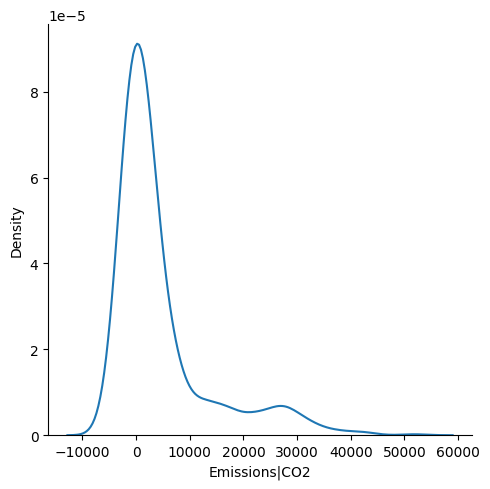

In [29]:

import seaborn as sns
sns.displot(data.iloc[:, outcome_interest],kind='kde')

In [30]:
#define threshold for outcome of interest

threshold_interest = 0

x = data.iloc[:, factors]
y = data.iloc[:, outcome_interest].values < threshold_interest

print(f"There are {sum(y)} cases of interest, out of {len(y)} scenarios")

There are 276 cases of interest, out of 763 scenarios


In [76]:
# from ema_workbench.analysis import cart

# cart_alg = cart.CART(x, y)
# cart_alg.build_tree()

# fig = cart_alg.show_tree()
# fig.set_size_inches((18, 12))
# plt.show()

In [32]:
#PRIM analysis
from ema_workbench.analysis import prim
from ema_workbench.util import ema_logging

#ema_logging.log_to_stderr(ema_logging.INFO);

In [33]:
prim_alg = prim.Prim(x, y)
box1 = prim_alg.find_box()

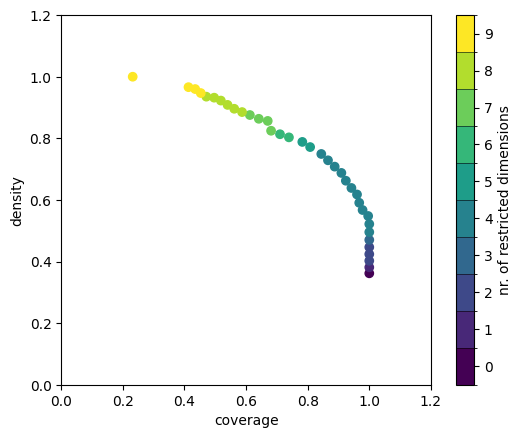

In [34]:
#Visualize first box tradeoff
box1.show_tradeoff()
plt.show()

In [35]:
box1.inspect_tradeoff()

alt.VConcatChart(...)

In [22]:
box1.inspect(style='data')

[(coverage     0.242754
  density      1.000000
  id          34.000000
  k           67.000000
  mass         0.087811
  mean         1.000000
  n           67.000000
  res_dim      8.000000
  Name: 34, dtype: float64,
                               box 34                                     
                                  min          max  qp value      qp value
  Final Energy             123.525545   325.446548  1.000000  1.000000e+00
  Primary Energy|Coal        0.000000    24.063175       NaN  3.813471e-01
  Primary Energy|Oil         0.000000    30.883900       NaN  4.046299e-03
  Primary Energy|Gas         2.006946    31.980281  1.000000  1.332966e-08
  Primary Energy|Nuclear     0.856996    89.632403  0.009212           NaN
  Primary Energy|Solar      36.943679   184.456750  1.000000  1.000000e+00
  Primary Energy|Wind       44.093828   136.649116  0.004046           NaN
  Population              3715.727807  3769.341062  0.074730  6.488923e-02)]

In [60]:
emissions_thr = data["Emissions|CO2"].median()
energy_thr = data["Final_Energy_per_capita"].median()

print(emissions_thr)
print(energy_thr)

1430.1851
0.06683006175297004


In [61]:
def classify(row):

    if row["Emissions|CO2"] <= emissions_thr:
        if row["Final_Energy_per_capita"] >= energy_thr:
            return "Sustainable Development"

        else:
            return "Energy Poverty Transition"

    else:
        if row["Final_Energy_per_capita"] >= energy_thr:
            return "Carbon Intensive Growth"

        else:
            return "High Carbon Poverty"

data["quadrant"] = data.apply(classify, axis=1)

In [62]:
data["quadrant"].value_counts()

,count
quadrant,
Energy Poverty Transition,237
Carbon Intensive Growth,237
Sustainable Development,145
High Carbon Poverty,144


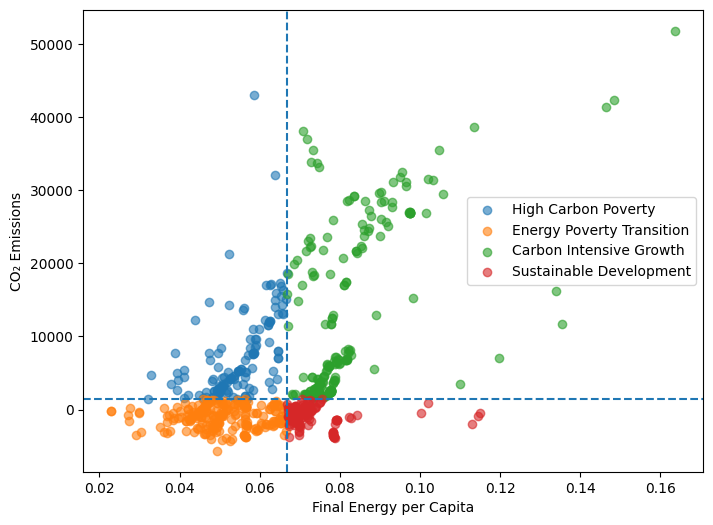

In [63]:
plt.figure(figsize=(8,6))

for q in data["quadrant"].unique():

    subset = data[data["quadrant"] == q]

    plt.scatter(
        subset["Final_Energy_per_capita"],
        subset["Emissions|CO2"],
        alpha=0.6,
        label=q
    )

plt.axhline(emissions_thr, ls="--")
plt.axvline(energy_thr, ls="--")

plt.xlabel("Final Energy per Capita")
plt.ylabel("CO₂ Emissions")
plt.legend()
plt.show()

In [64]:
y_sd = (
    data["quadrant"] == "Sustainable Development"
).astype(int)

prim_sd = prim.Prim(x, y_sd.values)
box_sd = prim_sd.find_box()

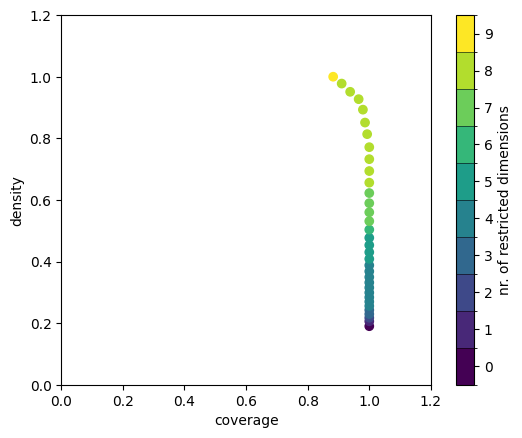

In [66]:
box_sd.show_tradeoff()
plt.show()

In [68]:
box_sd.inspect(style='data')

[(coverage      0.882759
  density       1.000000
  id           33.000000
  k           128.000000
  mass          0.167759
  mean          1.000000
  n           128.000000
  res_dim       9.000000
  Name: 33, dtype: float64,
                               box 33                                         
                                  min          max      qp value      qp value
  Final Energy             252.997830   445.670154  8.625938e-20           NaN
  Primary Energy           114.091375   472.431100           NaN  1.000000e+00
  Primary Energy|Oil         0.000000    28.556050           NaN  4.255112e-08
  Primary Energy|Gas         0.000946    57.507150           NaN  3.721635e-01
  Primary Energy|Biomass    27.222749   120.221200  5.633014e-02           NaN
  Primary Energy|Nuclear     7.833850    89.632403  2.840939e-03           NaN
  Primary Energy|Solar      63.332917   211.749100  1.000000e+00           NaN
  Primary Energy|Wind       43.984784   136.649116  1.000000e

In [65]:
y_hcp = (
    data["quadrant"] == "High Carbon Poverty"
).astype(int)

prim_hcp = prim.Prim(x, y_hcp.values)
box_hcp = prim_hcp.find_box()

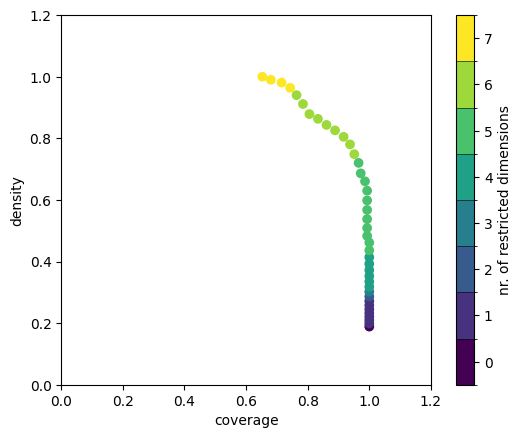

In [67]:
box_hcp.show_tradeoff()
plt.show()

In [69]:
box_hcp.inspect(style='data')

[(coverage     0.652778
  density      1.000000
  id          39.000000
  k           94.000000
  mass         0.123198
  mean         1.000000
  n           94.000000
  res_dim      7.000000
  Name: 39, dtype: float64,
                              box 39                                    
                                 min         max  qp value      qp value
  Final Energy            140.862500  247.902563  1.000000  1.133145e-15
  Primary Energy|Coal      11.169937  389.182800  0.000280           NaN
  Primary Energy|Gas       18.586978   66.093417  0.000202  3.850728e-01
  Primary Energy|Biomass    1.076145   64.326983       NaN  4.406908e-03
  Primary Energy|Nuclear    0.000000   12.586724       NaN  1.179282e-04
  Primary Energy|Solar     19.272784  211.749100  0.055435           NaN
  Primary Energy|Wind       2.993990   78.046850       NaN  7.661432e-03)]

In [70]:
y_cig = (
    data["quadrant"] == "Carbon Intensive Growth"
).astype(int)

prim_cig = prim.Prim(x, y_cig.values)
box_cig = prim_cig.find_box()

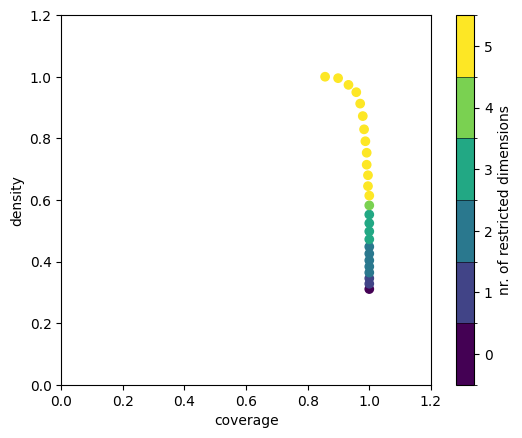

In [74]:
box_cig.show_tradeoff()
plt.show()

In [71]:
box_cig.inspect(style='data')

[(coverage      0.856540
  density       1.000000
  id           25.000000
  k           203.000000
  mass          0.266055
  mean          1.000000
  n           203.000000
  res_dim       5.000000
  Name: 25, dtype: float64,
                              box 25                                    
                                 min         max      qp value  qp value
  Final Energy            256.180519  445.670154  1.944390e-14       NaN
  Primary Energy|Coal       1.189750  389.182800  7.158775e-03       NaN
  Primary Energy|Oil        1.444633  153.008204  1.000000e+00       NaN
  Primary Energy|Gas       49.439994  103.002726  1.548755e-05       NaN
  Primary Energy|Nuclear    0.000000   47.763054           NaN  0.386423)]

In [72]:
y_ept = (
    (data["Emissions|CO2"] <= emissions_thr) &
    (data["Final_Energy_per_capita"] < energy_thr)
).astype(int)

prim_ept = prim.Prim(x, y_ept.values)
box_ept = prim_ept.find_box()

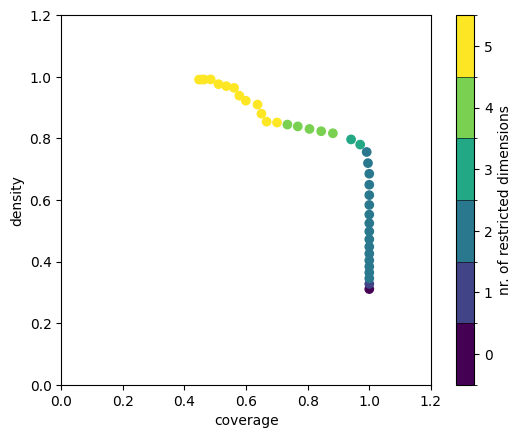

In [75]:
box_ept.show_tradeoff()
plt.show()

In [73]:
box_ept.inspect(style='data')

[(coverage      0.485232
  density       0.991379
  id           37.000000
  k           115.000000
  mass          0.152031
  mean          0.991379
  n           116.000000
  res_dim       5.000000
  Name: 37, dtype: float64,
                               box 37                                     
                                  min          max  qp value      qp value
  Final Energy              77.165300   249.792942       NaN  2.181877e-27
  Primary Energy|Coal        0.000000    21.793700       NaN  7.394033e-05
  Primary Energy|Oil         0.000000    26.663343       NaN  9.605423e-19
  Primary Energy|Biomass    32.482494   120.221200  0.218513           NaN
  Population              3079.042954  3796.119556  0.264471  1.585782e-01)]